In [46]:
from datetime import datetime
import numpy as np

from IPython.display import Image, display
import ROOT

In [47]:
# datafilename = './data_histos_trigeffNEW.root'
datafilename = './data_histos_trigeffTRY.root'
datafile = ROOT.TFile(datafilename)

In [48]:
# Make trigger efficiency plots

def ploteff_trigger(refvar, targetvar, binedges, *, logy=False, logx=False):
    # Create a canvas
    now_str = datetime.now().strftime("%Y_%m_%d_%H_%M_%S")
    binedges = np.array(binedges, dtype=np.float64)

    c = ROOT.TCanvas("c"+now_str, "c"+now_str, 1600, 600)
    ROOT.gStyle.SetOptStat(0)
    c.Divide(2, 1)

    c.cd(1)
    
    refvarhists = datafile.Get(refvar)
    targetvarhists = datafile.Get(targetvar)

    if logy:
        ROOT.gPad.SetLogy()
    if logx:
            ROOT.gPad.SetLogx()

    newrefvarhist = refvarhists.Rebin(len(binedges)-1, refvar+'_rebinned', binedges)
    newtargetvarhist = targetvarhists.Rebin(len(binedges)-1, targetvar+'_rebinned', binedges)

    newrefvarhist.SetLineColor(ROOT.kBlue)
    newrefvarhist.SetLineWidth(2)
    newtargetvarhist.SetLineColor(ROOT.kRed)
    newtargetvarhist.SetLineWidth(2)

    newrefvarhist.SetMinimum(1) 

    newrefvarhist.Draw("HIST SAME E1")
    newtargetvarhist.Draw("HIST SAME E1")

    c.Update()

    c.cd(2)

    if logx:
        ROOT.gPad.SetLogx()
    

    plot_eff = ROOT.TEfficiency(newtargetvarhist, newrefvarhist)

    plot_eff.SetLineWidth(2)

    plot_eff.Draw("AP")

    c.Update()

    plotname = f"plots/comapre_{targetvar}_{now_str}.png"
    c.SaveAs(plotname)
    return plotname   

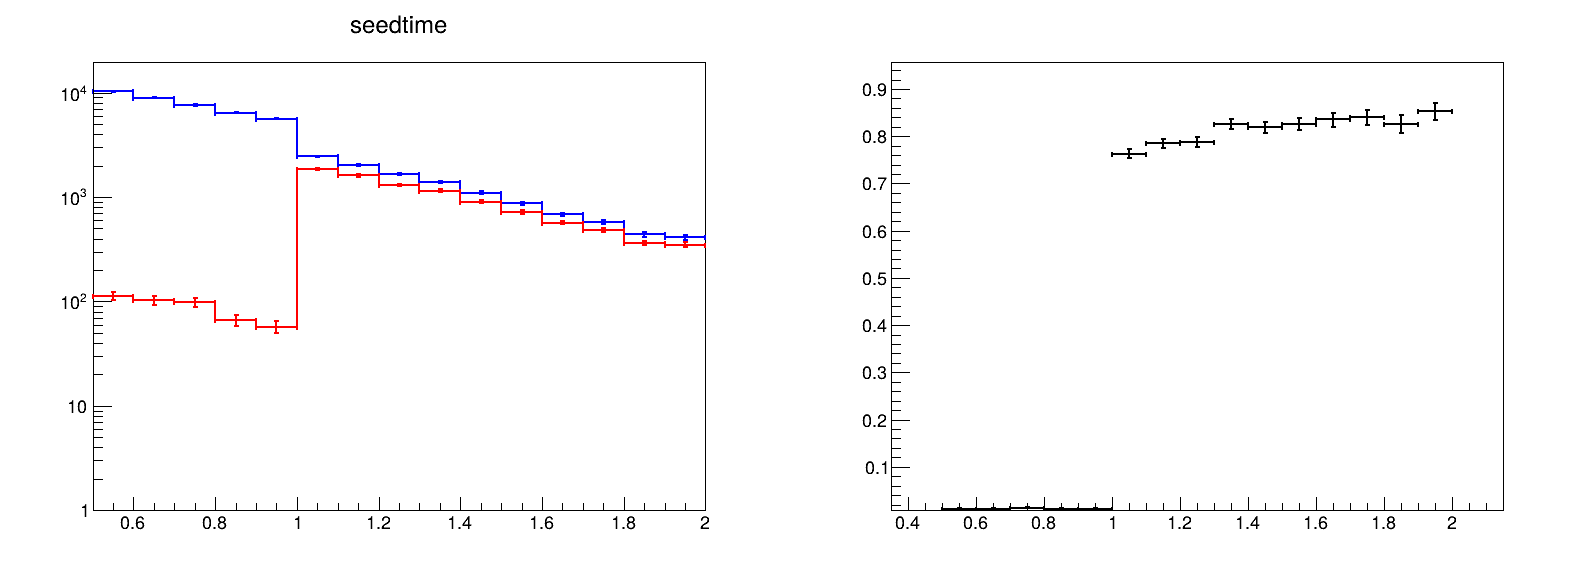

Info in <TCanvas::Print>: png file plots/comapre_tidhlt_elprobe_inZwindow_seedtime_2025_06_17_16_09_43.png has been created


In [49]:
stime = ploteff_trigger('tid_elprobe_inZwindow_seedtime', 'tidhlt_elprobe_inZwindow_seedtime', 
                       np.arange(0.5, 2.1, 0.1), 
                       logy=True)
display(Image(filename=stime))

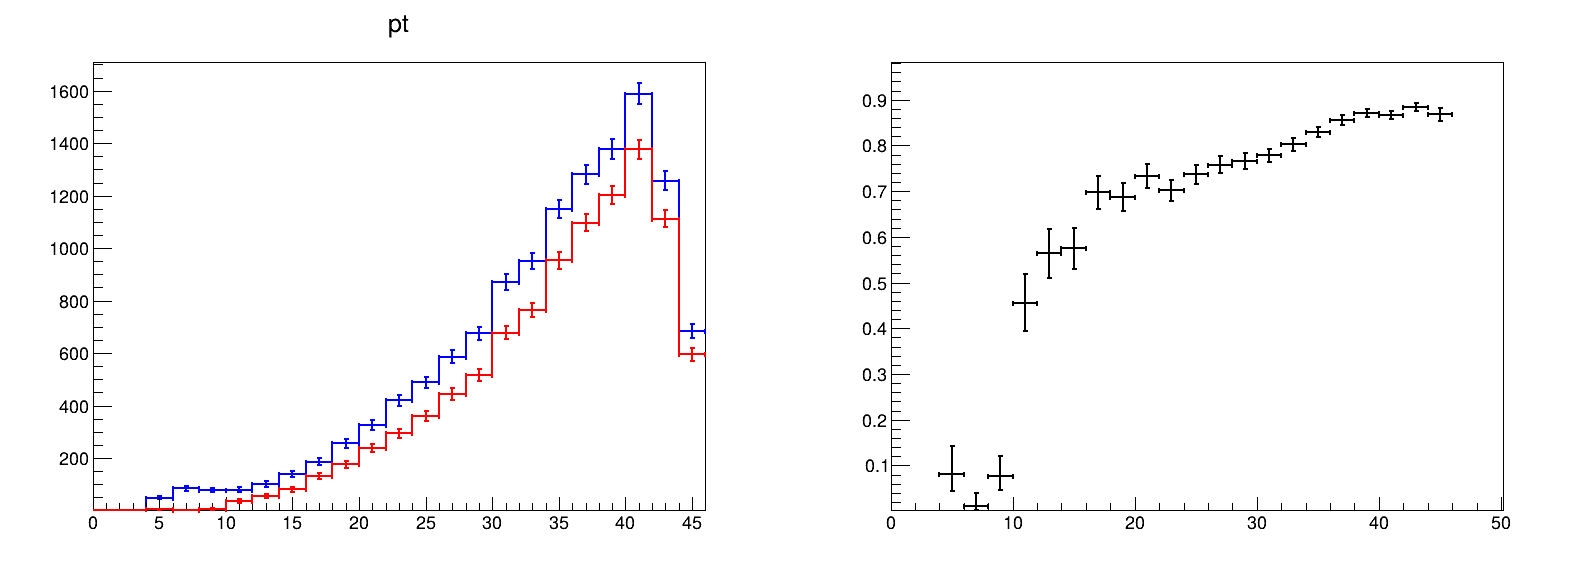

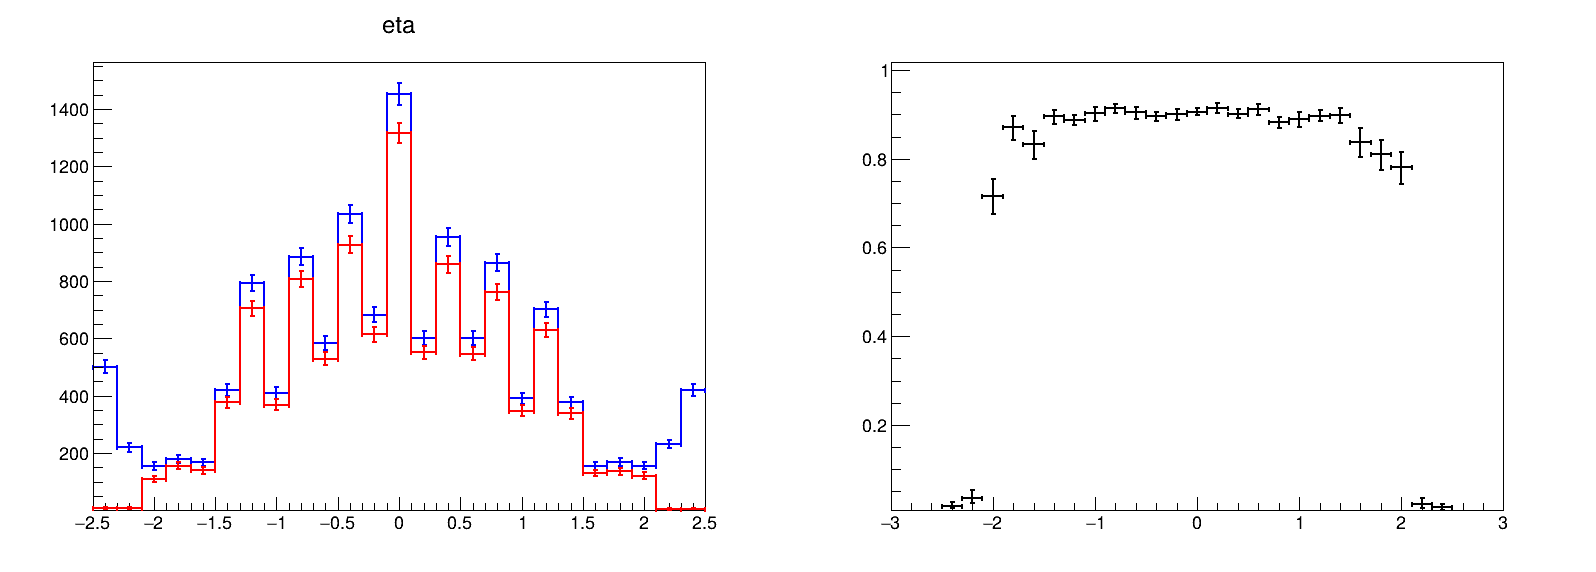

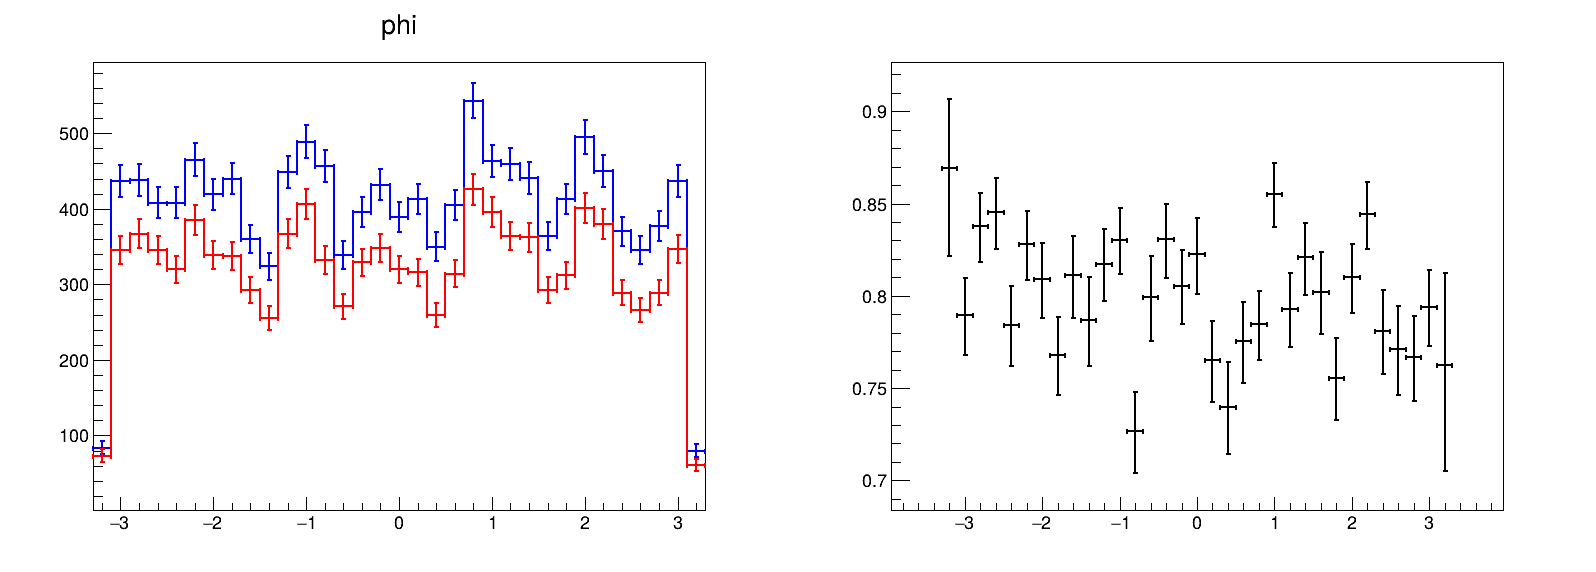

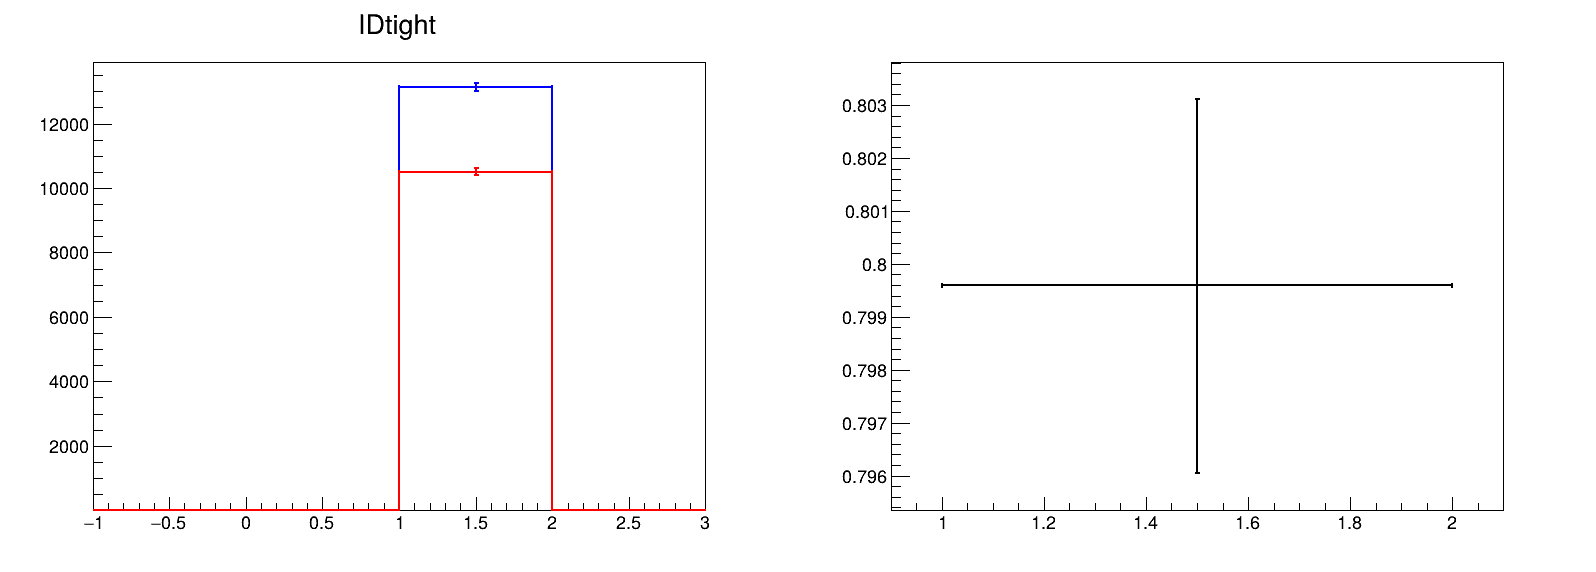

Info in <TCanvas::Print>: png file plots/comapre_tid1nshlt_elprobe_inZwindow_pt_2025_06_17_16_10_44.png has been created
Info in <TCanvas::Print>: png file plots/comapre_tid1nshlt_elprobe_inZwindow_eta_2025_06_17_16_10_44.png has been created
Info in <TCanvas::Print>: png file plots/comapre_tid1nshlt_elprobe_inZwindow_phi_2025_06_17_16_10_44.png has been created
Info in <TCanvas::Print>: png file plots/comapre_tid1nshlt_elprobe_inZwindow_IDtight_2025_06_17_16_10_44.png has been created


In [51]:
ranges = {'pt': np.arange(0, 48, 2), 
          'eta': np.arange(-2.5, 2.7, 0.2), 
          'phi': np.arange(-3.3, 3.5, 0.2), 
          # 'seedtime': np.arange(-5, 5, 0.1), 
          'IDtight': np.arange(-1, 4, 1) 
        }
# for var in ['pt', 'eta', 'phi', 'seedtime', 'IDtight']:
for var in ['pt', 'eta', 'phi', 'IDtight']:
  plot = ploteff_trigger(f'tid1ns_elprobe_inZwindow_{var}', f'tid1nshlt_elprobe_inZwindow_{var}', ranges[var])
  display(Image(filename=plot))